#### Find the optimal depth (number of hidden layers) and width(number of neurons in each hidden layer) for the neural network designed in Question 1 and 2.

##### Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. You may consider different number of neurons for each hidden layer within an architecture. Continue using 5-fold cross validation on the training dataset. 

##### Identify the architecture with the highest validation accuracy among all tested combinations. 

##### Explain the possible reasons why it performed better than the other architectures. 

##### In general, discuss whether accuracy alone is sufficient when selecting the best model. Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.

##### [optional + 2 marks] Implement an alternative approach that searches through these combinations that could significantly reduce the computational time but achieve similar search results, without enumeration all the possibilities.




This might take a while to run, so plan your time carefully.

#### 1.Firstly, we import relevant libraries.

In [4]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from common_utils import set_seed
from common_utils import split_dataset, preprocess_dataset
from common_utils import MLP, loss_fn, CustomDataset, EarlyStopper
from common_utils import train_loop, test_loop

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


#### 2. To reduce repeated code, place your

- network (MLP defined in QA1)
- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)

in a separate file called **common_utils.py**

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [7]:
no_labels = 1
no_features = 77
no_hidden = 128

dropout_rate = 0.3

no_of_epochs = 200

learning_rate = 0.0005
weight_decay = 0.0005
early_stopping_patience = 5
batch_size = 64

seed = 10
no_of_folds = 5

depth_of_layer = [1, 2, 3]
no_of_neuron = [64, 128, 256]

set_seed(seed)

In [8]:
def preprocess(df):
    x_train, y_train, x_test, y_test = split_dataset(df = df, columns_to_drop = ['filename', 'label'], test_size = 0.25, random_state = seed)
    
    return x_train, y_train, x_test, y_test

df = pd.read_csv('simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = preprocess(df)

#### 3. Perform hyperparameter tuning for different number of  hidden layers and neurons with 5-fold cross validation.

In [10]:
def train(model, X_train_scaled, y_train2, X_val_scaled, y_val2, learning_rate):

    train_data = CustomDataset(X_train_scaled, y_train2)
    val_data = CustomDataset(X_val_scaled, y_val2)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    early_stopper = EarlyStopper(patience=early_stopping_patience, min_delta=0)

    train_accuracies, train_losses = [], []
    test_accuracies, test_losses = [], []
    times = []

    epoch_count = 0
    for y in range(no_of_epochs):
        epoch_count += 1
        tr_loss, tr_acc = train_loop(train_loader, model, loss_fn, optimizer)
        test_loss, test_acc = test_loop(val_loader, model, loss_fn)

        train_accuracies.append(tr_acc)
        test_accuracies.append(test_acc)
        train_losses.append(tr_loss)
        test_losses.append(test_loss)
        times.append(epoch_count)

        if early_stopper.early_stop(test_loss):
            break
    

    return train_accuracies, train_losses, test_accuracies, test_losses, times

In [11]:
def find_optimal_hyperparameter(X_train, y_train, parameters, mode, learning_rate):
    kf = KFold(n_splits=no_of_folds, shuffle=True, random_state=seed)

    cross_validation_accuracies = {}
    cross_validation_times      = {}

    for arch in parameters:
        fold_val_accuracies = []
        fold_epochs         = []
        print(f"-----------------------------------------------------------------------------------------------")
        print(f"Current Architecture is {len(arch)} layers which is {arch}\n")

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            # ── Fold split + scale ─────────────────────────
            X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            X_fold_train_scaled, X_fold_val_scaled = preprocess_dataset(X_fold_train, X_fold_val)

            # ── Model ──────────────────────────────────────
            set_seed(seed)
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model = MLP(no_features=no_features, hidden_layers=arch, no_labels=no_labels, dropout_rate=dropout_rate).to(device)

            #── Train ──────────────────────────────────────
            _, _, test_accs, _, times = train(model, X_fold_train_scaled, y_fold_train,
                                                     X_fold_val_scaled,   y_fold_val,
                                                     learning_rate)

            fold_val_accuracies.append(test_accs[-1])
            fold_epochs.append(times[-1])
            print(f"  [{mode}={arch}] Fold {fold+1} | Val Acc: {test_accs[-1]:.4f} | Epochs: {times[-1]}")

        avg_acc    = sum(fold_val_accuracies) / len(fold_val_accuracies)
        avg_epochs = sum(fold_epochs)         / len(fold_epochs)

        arch_key = str(arch)
        cross_validation_accuracies[arch_key] = avg_acc
        cross_validation_times[arch_key]      = avg_epochs
        print(f"\n[{mode}={arch}] Avg Val Acc: {avg_acc:.4f} | Avg Epochs: {avg_epochs:.1f}")
        print(f"-----------------------------------------------------------------------------------------------")

    return cross_validation_accuracies, cross_validation_times

In [18]:
optimal_lr = learning_rate
parameters = [
    # 1 layer (3 combinations)
    [64],
    [128],
    [256],

    # 2 layers (9 combinations)
    [64,  64],
    [64,  128],
    [64,  256],
    [128, 64],
    [128, 128],
    [128, 256],
    [256, 64],
    [256, 128],
    [256, 256],

    # 3 layers (27 combinations)
    [64,  64,  64],
    [64,  64,  128],
    [64,  64,  256],
    [64,  128, 64],
    [64,  128, 128],
    [64,  128, 256],
    [64,  256, 64],
    [64,  256, 128],
    [64,  256, 256],
    [128, 64,  64],
    [128, 64,  128],
    [128, 64,  256],
    [128, 128, 64],
    [128, 128, 128],
    [128, 128, 256],
    [128, 256, 64],
    [128, 256, 128],
    [128, 256, 256],
    [256, 64,  64],
    [256, 64,  128],
    [256, 64,  256],
    [256, 128, 64],
    [256, 128, 128],
    [256, 128, 256],
    [256, 256, 64],
    [256, 256, 128],
    [256, 256, 256]
]

cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train.to_numpy(), y_train, parameters, 'architecture', optimal_lr)

-----------------------------------------------------------------------------------------------
Current Architecture is 1 layers which is [64]

  [architecture=[64]] Fold 1 | Val Acc: 0.6241 | Epochs: 31
  [architecture=[64]] Fold 2 | Val Acc: 0.6363 | Epochs: 32
  [architecture=[64]] Fold 3 | Val Acc: 0.6587 | Epochs: 41
  [architecture=[64]] Fold 4 | Val Acc: 0.6112 | Epochs: 20
  [architecture=[64]] Fold 5 | Val Acc: 0.6565 | Epochs: 61

[architecture=[64]] Avg Val Acc: 0.6374 | Avg Epochs: 37.0
-----------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------------
Current Architecture is 1 layers which is [128]

  [architecture=[128]] Fold 1 | Val Acc: 0.6440 | Epochs: 31
  [architecture=[128]] Fold 2 | Val Acc: 0.6716 | Epochs: 32
  [architecture=[128]] Fold 3 | Val Acc: 0.6466 | Epochs: 25
  [architecture=[128]] Fold 4 | Val Acc: 0.6571 | Epochs: 35
  [architec

#### 4. Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. 

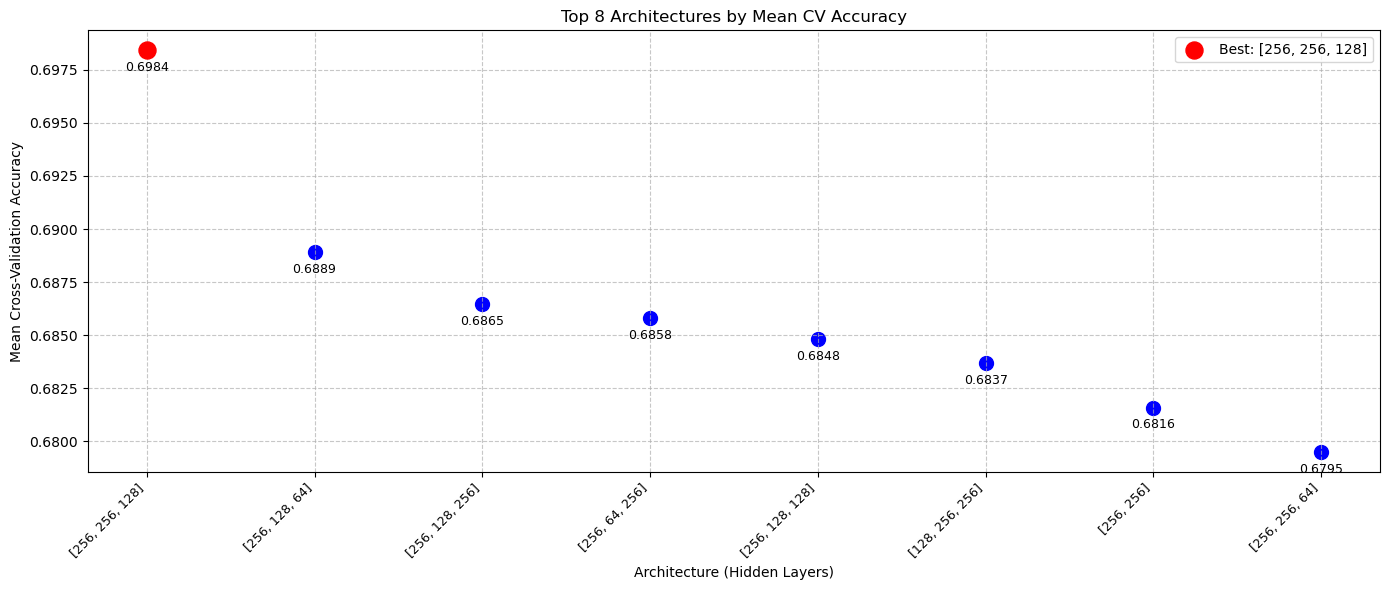


Top 8 Architectures:
Rank   Architecture              CV Accuracy    
----------------------------------------------
1      [256, 256, 128]           0.6984
2      [256, 128, 64]            0.6889
3      [256, 128, 256]           0.6865
4      [256, 64, 256]            0.6858
5      [256, 128, 128]           0.6848
6      [128, 256, 256]           0.6837
7      [256, 256]                0.6816
8      [256, 256, 64]            0.6795


In [21]:
# Sort by accuracy and take top 8
sorted_archs = sorted(cross_validation_accuracies.items(), key=lambda x: x[1], reverse=True)
top8_archs   = sorted_archs[:8]

top8_labels  = [item[0] for item in top8_archs]
top8_accs    = [item[1] for item in top8_archs]
x_pos        = range(len(top8_labels))

plt.figure(figsize=(14, 6))
plt.scatter(x_pos, top8_accs, color='blue', s=100)

# highlight best in red
plt.scatter(0, top8_accs[0], color='red', s=150, zorder=5, label=f'Best: {top8_labels[0]}')

# annotate below each dot
for i in range(len(top8_labels)):
    plt.annotate(f'{top8_accs[i]:.4f}', (x_pos[i], top8_accs[i]),
                 textcoords="offset points",
                 xytext=(0, -15),
                 ha='center',
                 fontsize=9)

plt.xticks(x_pos, top8_labels, rotation=45, ha='right', fontsize=9)
plt.xlabel('Architecture (Hidden Layers)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('Top 8 Architectures by Mean CV Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Print top 8 table
print("\nTop 8 Architectures:")
print(f"{'Rank':<6} {'Architecture':<25} {'CV Accuracy':<15}")
print("-" * 46)
for i, (arch, acc) in enumerate(top8_archs):
    print(f"{i+1:<6} {arch:<25} {acc:.4f}")

5. Select the optimal combination for the depth and width. State the rationale for your selection.

In [ ]:
optimal_combination = []
reason = " "
# YOUR CODE HERE

6.Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.


In [ ]:
# YOUR CODE HERE

7.As you've astutely observed, we're facing a significant challenge in enumerating all possible combinations of widths and depths and searching over them. Given the circumstances, could you explore and implement a more efficient method for searching through these combinations that could significantly reduce the computational time but achieve similar search results?

In [ ]:
# YOUR CODE HERE